# 한우 등급 예측 — 탐색적 데이터 분석 (EDA)

기상청 빅데이터 콘테스트 주제2: 기상에 따른 한우 등급 예측

**데이터셋:**
| 파일 | 설명 | 행 수 | 변수 수 |
|------|------|------:|------:|
| `hanwoo_train.csv` | 도축·등급판정 훈련 데이터 | 2,408,699 | 23 |
| `hanwoo_weather.csv` | 기상 관측 데이터 | 973,248 | 7 |
| `hanwoo_area.csv` | 농장별 사육두수·면적 | 91,896 | 5 |
| `hanwoo_death.csv` | 폐사 기록 | 321,389 | 4 |
| `hanwoo_lineage.csv` | 혈통 정보 | 1,809,455 | 8 |

**예측 대상:** `LAST_GRADE` (최종 등급 = 육질등급 + 육량등급)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import platform, os, matplotlib

# 폰트 캐시 삭제 → 다음 import 시 자동 재빌드
cache_dir = matplotlib.get_cachedir()
for f in os.listdir(cache_dir):
    if f.startswith("fontlist"):
        os.remove(os.path.join(cache_dir, f))

# 폰트 매니저 메모리상 재초기화
fm._load_fontmanager(try_read_cache=False)

sns.set_theme(style="whitegrid")

if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    fm.fontManager.addfont(font_path)
    font_name = "Malgun Gothic"
elif platform.system() == "Darwin":
    font_name = "AppleGothic"
else:
    font_name = "NanumGothic"

# sans-serif 계열 1순위로 지정 (family='sans-serif'가 더 안정적)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [font_name] + plt.rcParams["font.sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
%matplotlib inline

print("적용 폰트 계열:", plt.rcParams["font.family"])
print("sans-serif 1순위:", plt.rcParams["font.sans-serif"][0])

적용 폰트 계열: ['sans-serif']
sans-serif 1순위: Malgun Gothic


---
## 1. 데이터 로드

In [2]:
train = pd.read_csv('data/hanwoo_train.csv', encoding='utf-8-sig')
weather = pd.read_csv('data/hanwoo_weather.csv', encoding='utf-8-sig')
area = pd.read_csv('data/hanwoo_area.csv', encoding='utf-8-sig')
death = pd.read_csv('data/hanwoo_death.csv', encoding='utf-8-sig')
lineage = pd.read_csv('data/hanwoo_lineage.csv', encoding='utf-8-sig')

# -99를 결측값으로 치환
MISSING = -99
replace_cols = ['BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT']
for col in replace_cols:
    train[col] = train[col].replace(MISSING, np.nan)

train['WGRADE'] = train['WGRADE'].replace('-99.0', np.nan)
death['DEAD_REASON'] = death['DEAD_REASON'].replace('-99', np.nan)

print(f'훈련 데이터: {train.shape[0]:,}행 × {train.shape[1]}열')

훈련 데이터: 2,408,699행 × 23열


---
## 2. 데이터 기본 정보

In [3]:
datasets = {
    '훈련(train)': train,
    '기상(weather)': weather,
    '사육면적(area)': area,
    '폐사(death)': death,
    '혈통(lineage)': lineage
}

for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'📋 {name}: {df.shape[0]:,}행 × {df.shape[1]}열')
    print(f'칼럼: {list(df.columns)}')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n결측값:')
        for col, cnt in missing.items():
            print(f'  {col}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
    else:
        print('결측값 없음')


📋 훈련(train): 2,408,699행 × 23열
칼럼: ['sido', 'sigungu', 'eupmyeondong', 'stn', 'ABATT_DATE', 'JUDGE_DATE', 'JUDGE_SEX', 'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'WGRADE', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT', 'AGE', 'BIRTH_YMD', 'CATTLE_NO', 'FARM_UNIQUE_NO', 'LAST_GRADE']

결측값:
  BACKFAT: 4,567 (0.2%)
  REA: 5,188 (0.2%)
  WINDEX: 5,252 (0.2%)
  WGRADE: 4,814 (0.2%)
  INSFAT: 5,331 (0.2%)
  YUKSAK: 5,269 (0.2%)
  FATSAK: 4,743 (0.2%)
  TISSUE: 5,320 (0.2%)
  GROWTH: 9 (0.0%)
  COST_AMT: 885,003 (36.7%)

📋 기상(weather): 973,248행 × 7열
칼럼: ['stn', 'date', 'ta_max', 'rn_day', 'ta_min', 'rhm_avg', 'ws_davg']
결측값 없음

📋 사육면적(area): 91,896행 × 5열
칼럼: ['FARM_UNIQUE_NO', 'C2023', 'C2024', 'C2025', 'AREA']
결측값 없음

📋 폐사(death): 321,389행 × 4열
칼럼: ['FARM_UNIQUE_NO', 'BIRTH_YMD', 'DEAD_YMD', 'DEAD_REASON']

결측값:
  DEAD_REASON: 234,276 (72.9%)

📋 혈통(lineage): 1,809,455행 × 8열
칼럼: ['CATTLE_NO', 'KPN_NO', 'FATHER_CATTLE_NO', 'MOTHER_ANIMAL_NO', 'F_GMOTHER_ANIMAL_NO', 'F_GFATHER_CATTLE_

In [4]:
train.head()

,sido,sigungu,eupmyeondong,stn,ABATT_DATE,JUDGE_DATE,JUDGE_SEX,WEIGHT,BACKFAT,REA,...,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD,CATTLE_NO,FARM_UNIQUE_NO,LAST_GRADE
0,강원특별자치도,정선군,북평면,563,2023-01-01,2023-01-02,암,218,3.0,44.0,...,6.0,7.0,5.0,9.0,NaN,76,20160915,mI4i8G0BJ8kWD6gdm77RmTzyuIx6N2ZMaZ7wFXx3xb4=,hqh4Qmh5g+ymbYtqjAeKeA==,3B
1,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,520,12.0,100.0,...,5.0,3.0,3.0,3.0,NaN,32,20200504,tMgfi1p35taO9GH4XN4x0bfO8czy79B8V9NyczRuV+8=,N5qW6dZ91QWCMHg/1kPdlA==,1B
2,경상북도,영주시,이산면,837,2023-01-01,2023-01-02,거세,452,14.0,104.0,...,4.0,3.0,1.0,3.0,NaN,29,20200803,mdsSD4/sB06U68LNT6P/GUwei2ISyIBZ+R04iLw2mX0=,5UbtU8TgV2yu3Y4/jxuNMQ==,1++B
3,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,454,12.0,95.0,...,5.0,3.0,1.0,3.0,NaN,32,20200510,LZWd4YatUD851LyC/LFXuxPW7KEXTwVWQONOwqrkLPI=,N5qW6dZ91QWCMHg/1kPdlA==,1++B
4,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,462,10.0,78.0,...,5.0,3.0,3.0,3.0,NaN,32,20200511,A4FF/dhr8vg7JeW/eqc3922pA69nEaLL/+uoAusZqyU=,N5qW6dZ91QWCMHg/1kPdlA==,1B


In [5]:
weather.head()

,stn,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg
0,95,2020-01-01,0.7,0.0,-9.0,78.4,0.7
1,95,2020-01-02,2.1,0.0,-4.7,87.8,0.7
2,95,2020-01-03,3.3,0.0,-8.4,82.0,0.6
3,95,2020-01-04,5.2,0.0,-9.7,79.3,0.6
4,95,2020-01-05,5.3,0.0,-10.4,78.3,0.5


In [6]:
area.head()

,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA
0,X8bGdfHedF2o5xSAAERtEA==,23.0,26.0,25.0,220.00
1,N9t4B2mc+EZsH7wBLT8U4Q==,37.0,34.0,32.0,431.05
2,DeEu4RIkIUXq7NyTBwD8vg==,10.0,5.0,3.0,265.82
3,fgQkQJ+iyrFZDHsC9ih9mQ==,35.0,41.0,40.0,593.80
4,2mUAsXfTviEJtFBM7s31uw==,16.0,14.0,15.0,155.61


In [7]:
death.head()

,FARM_UNIQUE_NO,BIRTH_YMD,DEAD_YMD,DEAD_REASON
0,WiJdwGdfb+CC7Jg0Pn/aLA==,20070621,20250107,NaN
1,gj6CI5LHYXz7druWs1ZEUQ==,20060705,20250106,NaN
2,We6zq4c9yoG5GKrt1CbrdA==,20080610,20250103,NaN
3,s67fGrSPXhX1Bgp+JDW9Aw==,20050408,20250108,NaN
4,3lGF4dGtWtydlceogBluUA==,20080425,20250109,NaN


In [8]:
lineage.head()

,CATTLE_NO,KPN_NO,FATHER_CATTLE_NO,MOTHER_ANIMAL_NO,F_GMOTHER_ANIMAL_NO,F_GFATHER_CATTLE_NO,M_GMOTHER_ANIMAL_NO,M_GFATHER_CATTLE_NO
0,yaSF9EHVPBIFeOdxL/st19so274mMHAbxmME5JhQ0Jk=,mgzxMpKRCOrwfHqsCHzP47qdLKwCfR8ULPzyRiJVOkM=,AMohGlr/7kUmTZcSjmBDCZP7fGvHMGm2uWw51JIprKc=,cMfffVbj3vfDem0QlY2ZOZphrIldXYc+f60y3Hvq9nI=,efoeB0IMVAIi87aCUIsPhGDfry4wx/cULq0c7MLKFA4=,SgXkbJ+3aQWEQl4EoT96zIyQAo5tEjvHfdMR2mvaVXw=,wV9qjXaPXOkYKpKj9nip78T5MB5AVUSkcK5tDT5O8e0=,Pd9ODUb0XUGA5X8xdQ5AdlNZk4cl7vCd/UfKUhXezYk=
1,iCeTx0O5z/M8GAcglblMDFVCzmvnkdPVRKTQtIN4ZFg=,mgzxMpKRCOrwfHqsCHzP47qdLKwCfR8ULPzyRiJVOkM=,AMohGlr/7kUmTZcSjmBDCZP7fGvHMGm2uWw51JIprKc=,0JDDs8FOPj0ZsxNi8H9ko/sBDa3eRTB9bq4nbuhtcpY=,efoeB0IMVAIi87aCUIsPhGDfry4wx/cULq0c7MLKFA4=,SgXkbJ+3aQWEQl4EoT96zIyQAo5tEjvHfdMR2mvaVXw=,SKOzaLpnj/ojtvXerWQzc1HSyU2kDhtQ42ShRDVA+/8=,Gt6xHYYq6gyhiQ2S6czPsYfvPNtj7D/O/Tw7yzi4e5w=
2,vI7joD/5v0T+wqvjC0d/36Sv5y+9NG18W+y2/YRVllg=,KDcckdOdPX/Uve2c5f7RNbAQrB27wyafOtzqX260DT4=,FXlabyH9KcP+VEzuDdo2xilVUs4PIl83AVIsv3AWiNc=,u6rUplX8Xi7ldmcYV1+AVtyCkMZLao7JzGOBuD1COMU=,Z7eNcRWyZHwpzEUJhPMNvbajt2EK/v1qGltu/05jQNw=,xJEKH2EwTkJaR/ajqNUgMSSlHOxsrEXijgN2Er6PBFo=,kluWj1LiM8I6nYWfDenO7q4tJySB2AVV8z9cMqweuXA=,kluWj1LiM8I6nYWfDenO7q4tJySB2AVV8z9cMqweuXA=
3,j0URLNNWbjl9ypDnsdULQAhvQ4roRAFjP0kGszyEXXw=,PBpDKzobFwTYitup5cJrqGpOK6iVZJvV6r42rmEbbZY=,A+eYuVUY8/QwN4+Ddgs7Tvko8TjAN7AtZv2+aZy0xIc=,fvUhHnLXiy3xTVKmqY62z+s5RlegNhPaR9ex1Gx0eN0=,+qwqADxeX1176gNXAgnIZjCeAdxDM1LrO3pn87MdVzA=,6LFovs6S310gxvJaixkryaO54hmEUBGq2C/pHCgq2No=,Ck6/PtPWiRKlWc9/jjgKjpepUIaUD2NlOlYzbbEzSOs=,Ju4e/qNWdk0qXYEO/m2Ypv7BGAwqhScFw+zq9k+mjKU=
4,kOnOAfd4lRrulCE9uv9ekwUcP/W9Hs41K1i5U0OLAfo=,+mx1i1sOZ7tc0lLUnrEQjGghLy+l5BH5XrTmY72A9Zc=,mAaX9QxFXASjT6u+keurKA90ZDThZfQ5xJzY6bv/6/8=,f7xH6ZSCkAVcPimjhYi5OqHYDXTX8GxNo+R7GeJYQ0s=,hyumffzX44tVUGJ22AnMUaD3t+jU7DWWPeGQzzrAQM8=,PJRSI2aIwE+wgp9nIHhFVxIm2gDfLdmeDbdUjDsn4GI=,FhYpc9/PEsQfoBSv2l3Ihz8r96yhBvEWup1GsUjhvXY=,H0hzRqFLWYoL0ncDgFrEGDeHw//E0XvfVXSi749m7Iw=


---
## 3. 훈련 데이터 기초 통계

In [9]:
train.describe().round(2)

,stn,WEIGHT,BACKFAT,REA,WINDEX,INSFAT,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD
count,2408699.00,2408699.00,2404132.00,2403511.00,2403447.00,2403368.00,2403430.00,2403956.00,2403379.00,2408690.00,1523696.00,2408699.00,2408699.00
mean,590.24,422.75,12.63,93.12,61.51,5.42,4.97,3.07,2.18,4.18,16661.81,42.57,20206114.74
std,252.00,79.84,5.45,15.06,1.82,2.20,0.49,0.37,1.06,2.15,4212.82,21.86,20525.88
min,93.00,3.00,1.00,1.00,29.19,1.00,1.00,1.00,1.00,1.00,0.00,1.00,19960101.00
25%,288.00,367.00,9.00,84.00,60.40,4.00,5.00,3.00,1.00,3.00,13900.00,31.00,20200520.00
50%,672.00,423.00,12.00,93.00,61.58,6.00,5.00,3.00,2.00,3.00,16949.00,33.00,20210516.00
75%,785.00,479.00,15.00,103.00,62.63,7.00,5.00,3.00,3.00,6.00,19400.00,47.00,20220501.00
max,964.00,881.00,98.00,196.00,77.32,9.00,8.00,8.00,5.00,9.00,150000.00,344.00,20250826.00


In [10]:
print('=== 성별 분포 ===')
print(train['JUDGE_SEX'].value_counts())
print(f'\n=== 시도별 건수 (상위 10) ===')
print(train['sido'].value_counts().head(10))

=== 성별 분포 ===
JUDGE_SEX
거세    1222465
암     1174414
수       11820
Name: count, dtype: int64

=== 시도별 건수 (상위 10) ===
sido
경상북도       605621
전라남도       409421
전북특별자치도    295666
충청남도       289493
경기도        214181
경상남도       203066
강원특별자치도    153026
충청북도       138979
울산광역시       20519
제주특별자치도     19448
Name: count, dtype: int64


---
## 4. 최종 등급 (LAST_GRADE) 분석

최종 등급 = 육질등급(1++, 1+, 1, 2, 3) + 육량등급(A, B, C)

In [11]:
# 육질등급·육량등급 분리
train['육질등급'] = train['LAST_GRADE'].str.extract(r'^(1\+\+|1\+|1|2|3|등외)')[0]
train['육량등급'] = train['LAST_GRADE'].str.extract(r'(A|B|C)$')[0]

grade_order = ['1++A','1++B','1++C','1+A','1+B','1+C','1A','1B','1C','2A','2B','2C','3A','3B','3C','등외']
quality_order = ['1++','1+','1','2','3','등외']
yield_order = ['A','B','C']

print('=== 최종 등급 분포 ===')
grade_counts = train['LAST_GRADE'].value_counts().reindex(grade_order).dropna()
print(grade_counts)

=== 최종 등급 분포 ===
LAST_GRADE
1++A    207026
1++B    319588
1++C    128997
1+A     167246
1+B     311222
1+C     130094
1A      168174
1B      299290
1C      116976
2A      127410
2B      195866
2C       62938
3A       47214
3B       97576
3C       23542
등외        5540
Name: count, dtype: int64


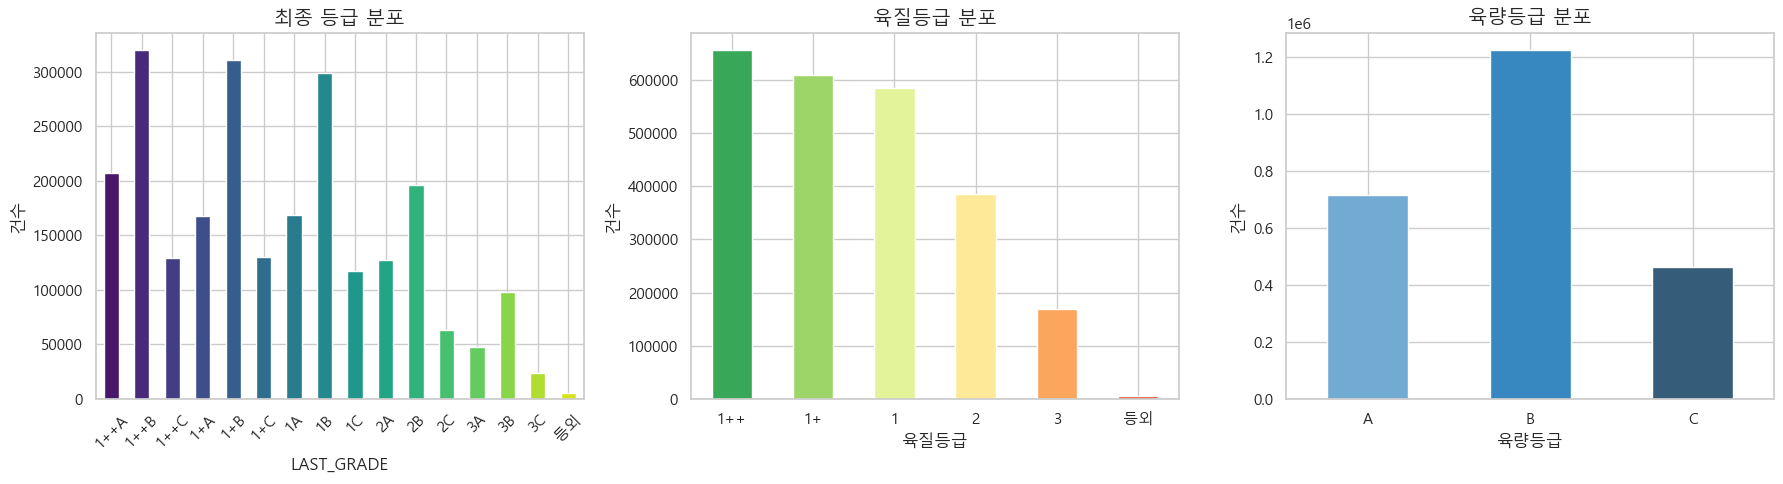

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 최종 등급 분포
colors = sns.color_palette('viridis', len(grade_counts))
grade_counts.plot.bar(ax=axes[0], color=colors)
axes[0].set_title('최종 등급 분포', fontsize=14)
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)

# 육질등급 분포
q_counts = train['육질등급'].value_counts().reindex(quality_order).dropna()
q_counts.plot.bar(ax=axes[1], color=sns.color_palette('RdYlGn_r', len(q_counts)))
axes[1].set_title('육질등급 분포', fontsize=14)
axes[1].set_ylabel('건수')
axes[1].tick_params(axis='x', rotation=0)

# 육량등급 분포
y_counts = train['육량등급'].value_counts().reindex(yield_order).dropna()
y_counts.plot.bar(ax=axes[2], color=sns.color_palette('Blues_d', len(y_counts)))
axes[2].set_title('육량등급 분포', fontsize=14)
axes[2].set_ylabel('건수')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

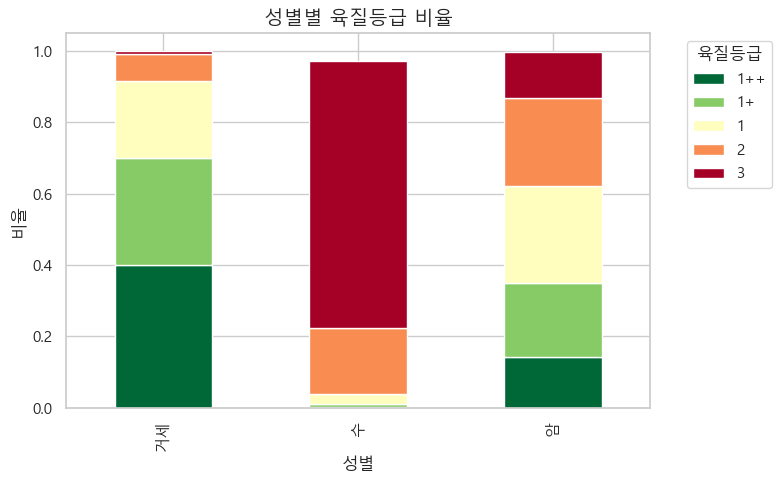

In [13]:
# 성별별 육질등급 비율
ct = pd.crosstab(train['JUDGE_SEX'], train['육질등급'], normalize='index')[quality_order[:-1]]
ct.plot.bar(stacked=True, figsize=(8, 5), colormap='RdYlGn_r')
plt.title('성별별 육질등급 비율', fontsize=14)
plt.ylabel('비율')
plt.xlabel('성별')
plt.legend(title='육질등급', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

---
## 5. 육량 관련 피처 분석

육량등급 결정 요소: **도체중량(WEIGHT)**, **등지방두께(BACKFAT)**, **배최장근단면적(REA)** → **육량지수(WINDEX)**

C:\Users\jaeyo\AppData\Local\Temp\ipykernel_13808\2864092215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
C:\Users\jaeyo\AppData\Local\Temp\ipykernel_13808\2864092215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
C:\Users\jaeyo\AppData\Local\Temp\ipykernel_13808\2864092215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
C:\Users\jaeyo\AppData\Local\Temp\ipykernel

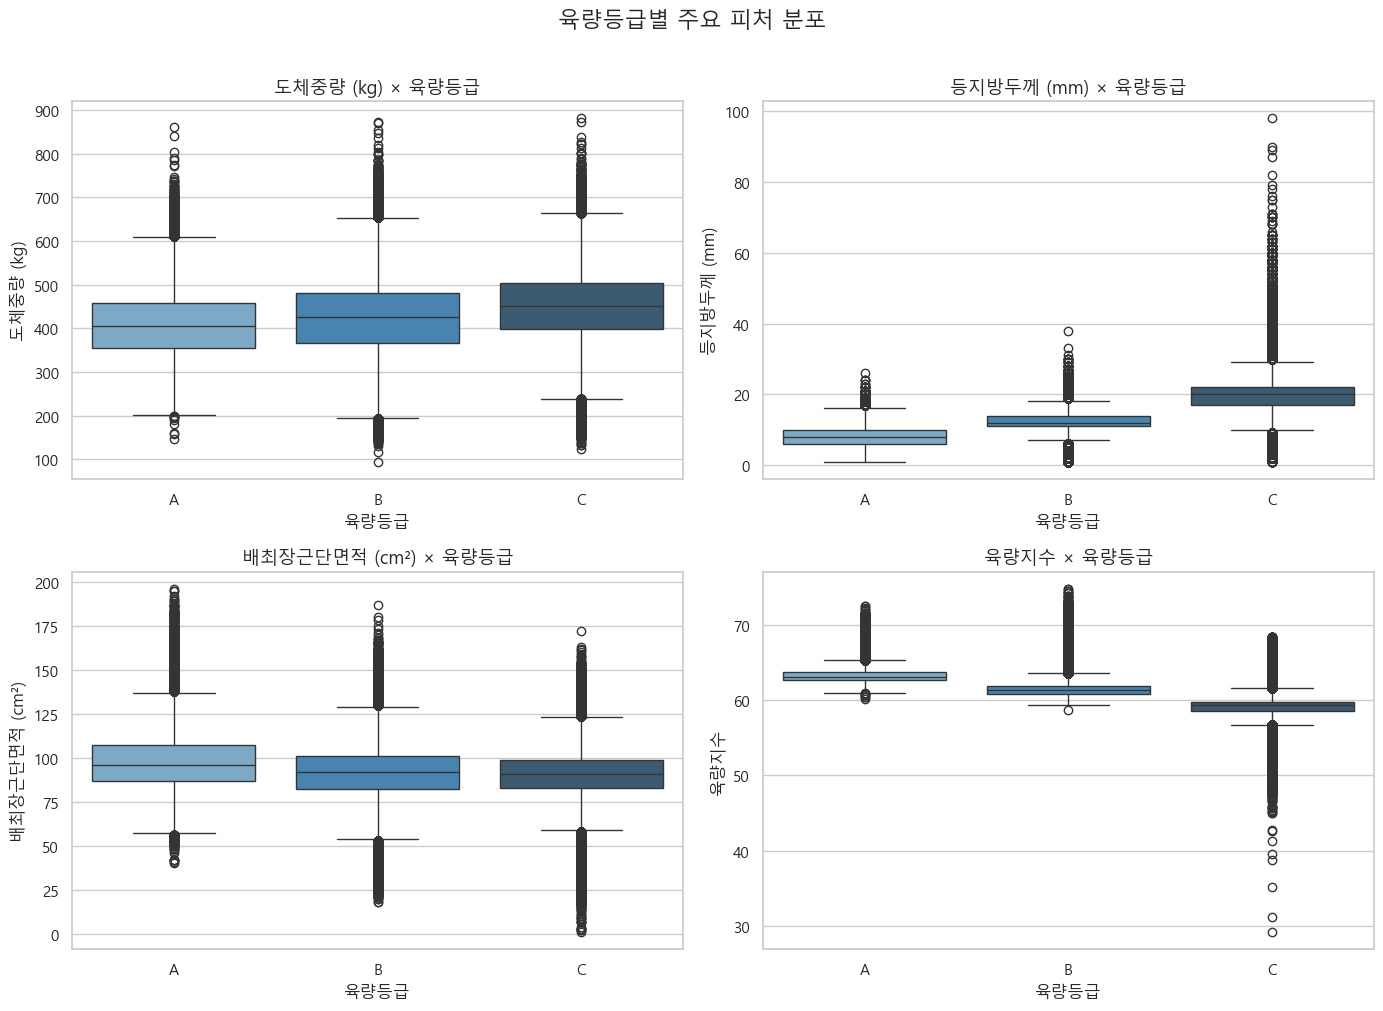

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, label in zip(
    axes.flat,
    ['WEIGHT', 'BACKFAT', 'REA', 'WINDEX'],
    ['도체중량 (kg)', '등지방두께 (mm)', '배최장근단면적 (cm²)', '육량지수']
):
    sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
                palette='Blues_d')
    ax.set_title(f'{label} × 육량등급', fontsize=13)
    ax.set_xlabel('육량등급')
    ax.set_ylabel(label)

plt.suptitle('육량등급별 주요 피처 분포', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. 육질 관련 피처 분석

육질등급 결정 요소: **근내지방도(INSFAT)**, **육색(YUKSAK)**, **지방색(FATSAK)**, **조직감(TISSUE)**, **성숙도(GROWTH)**

C:\Users\jaeyo\AppData\Local\Temp\ipykernel_13808\960382140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
C:\Users\jaeyo\AppData\Local\Temp\ipykernel_13808\960382140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
C:\Users\jaeyo\AppData\Local\Temp\ipykernel_13808\960382140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
C:\Users\jaeyo\AppData\Local\Temp\ipykernel

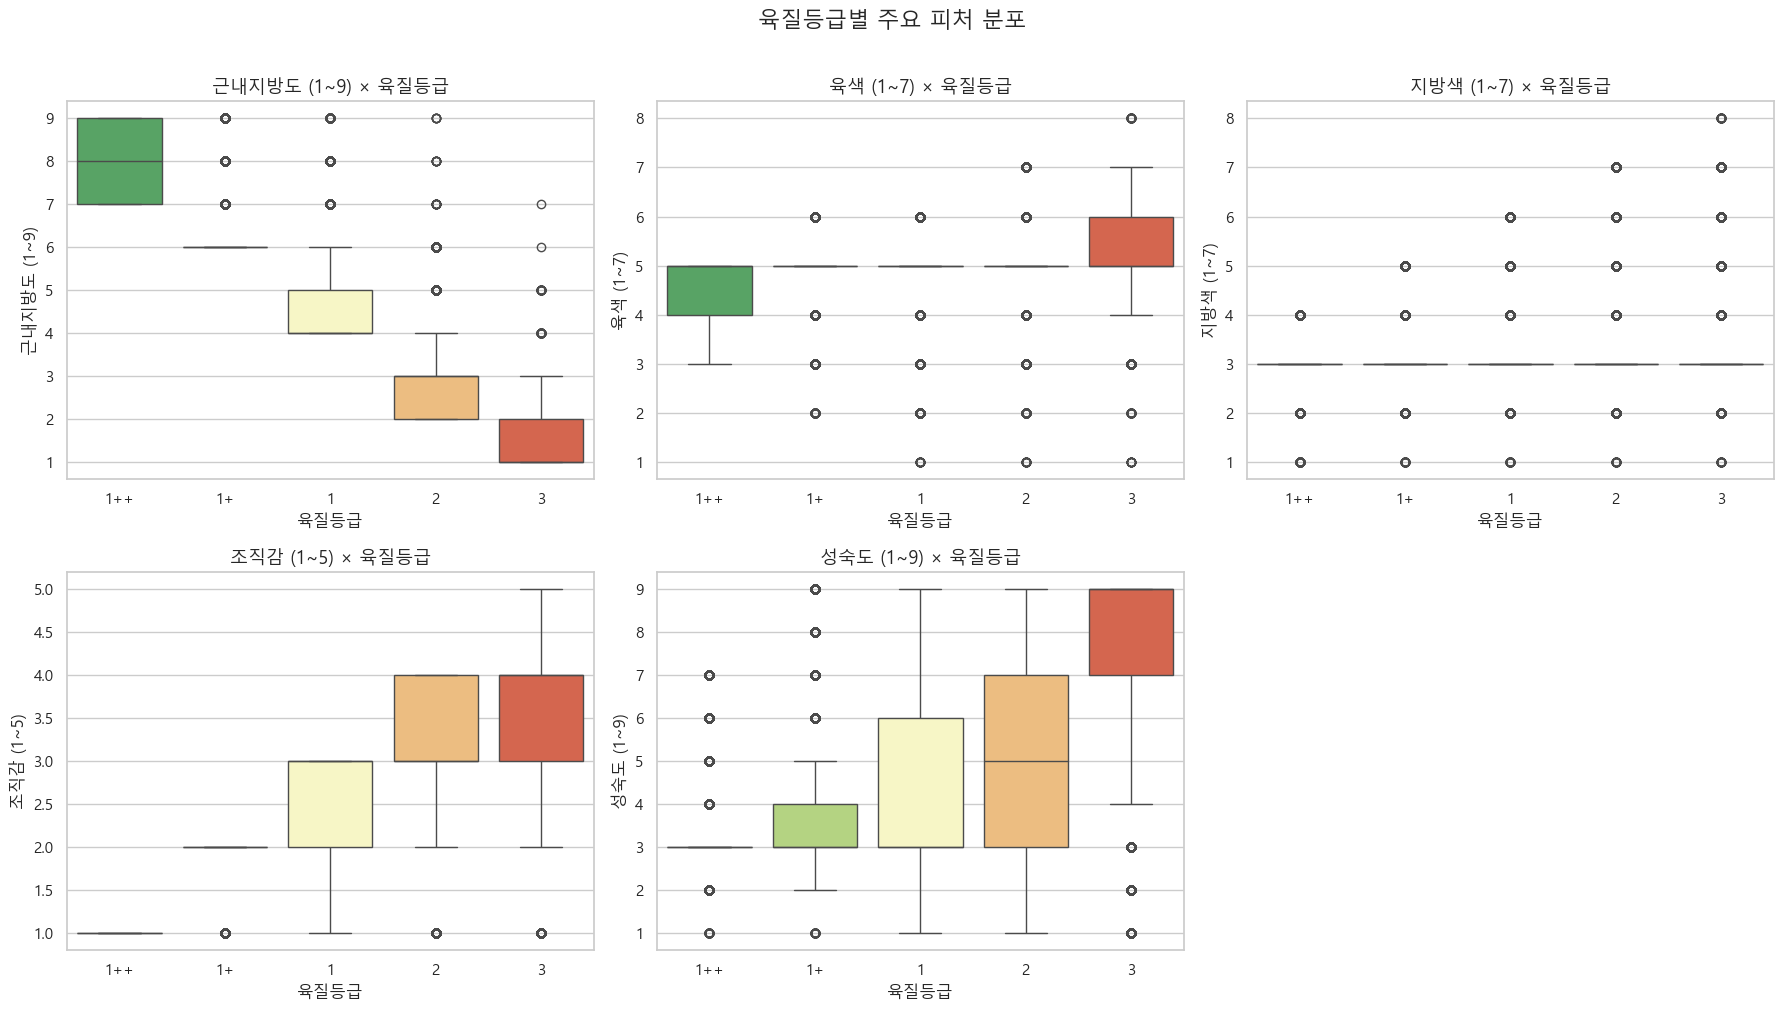

In [15]:
quality_cols = {
    'INSFAT': '근내지방도 (1~9)',
    'YUKSAK': '육색 (1~7)',
    'FATSAK': '지방색 (1~7)',
    'TISSUE': '조직감 (1~5)',
    'GROWTH': '성숙도 (1~9)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flat

for (col, label), ax in zip(quality_cols.items(), axes_flat):
    sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
                ax=ax, palette='RdYlGn_r')
    ax.set_title(f'{label} × 육질등급', fontsize=13)
    ax.set_xlabel('육질등급')
    ax.set_ylabel(label)

axes_flat[-1].axis('off')  # 빈 칸 숨기기
plt.suptitle('육질등급별 주요 피처 분포', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. 월령(AGE) & 도체중량(WEIGHT) 분석

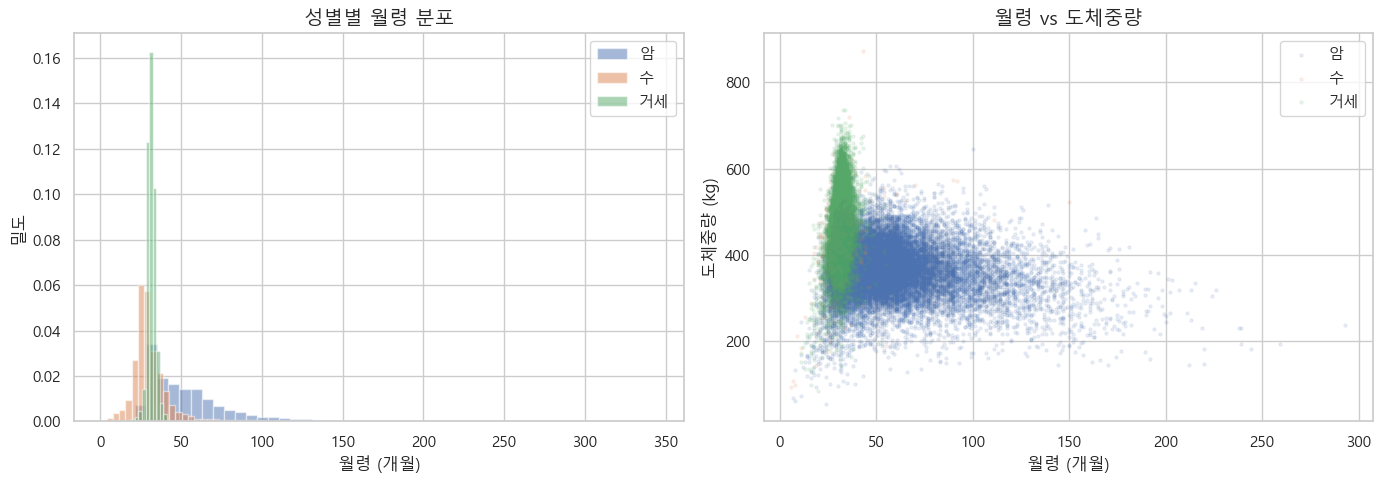

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성별별 월령 분포
for sex in ['암', '수', '거세']:
    subset = train[train['JUDGE_SEX'] == sex]['AGE']
    axes[0].hist(subset, bins=50, alpha=0.5, label=sex, density=True)
axes[0].set_title('성별별 월령 분포', fontsize=14)
axes[0].set_xlabel('월령 (개월)')
axes[0].set_ylabel('밀도')
axes[0].legend()

# 월령 vs 도체중량 (성별)
sample = train.sample(min(50000, len(train)), random_state=42)
for sex in ['암', '수', '거세']:
    s = sample[sample['JUDGE_SEX'] == sex]
    axes[1].scatter(s['AGE'], s['WEIGHT'], alpha=0.1, s=5, label=sex)
axes[1].set_title('월령 vs 도체중량', fontsize=14)
axes[1].set_xlabel('월령 (개월)')
axes[1].set_ylabel('도체중량 (kg)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. 수치형 피처 상관관계

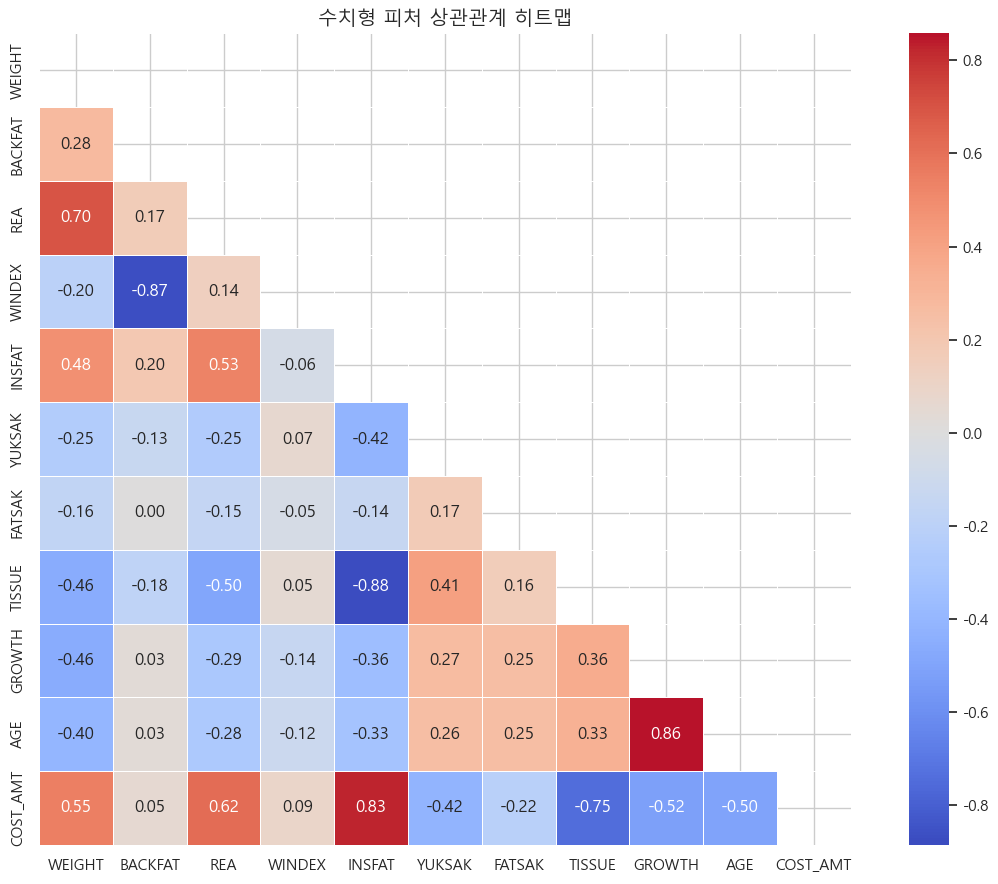

In [17]:
numeric_cols = ['WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'AGE', 'COST_AMT']
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('수치형 피처 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. 시도별 등급 분석

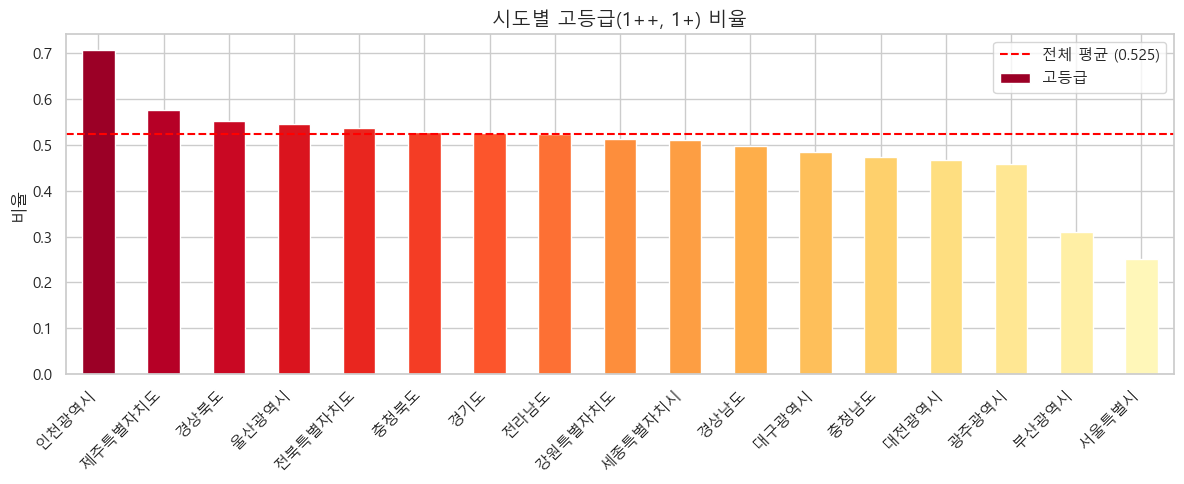

In [18]:
# 시도별 1++/1+ 비율
train['고등급'] = train['육질등급'].isin(['1++', '1+'])
sido_rate = train.groupby('sido')['고등급'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sido_rate.plot.bar(ax=ax, color=sns.color_palette('YlOrRd_r', len(sido_rate)))
ax.set_title('시도별 고등급(1++, 1+) 비율', fontsize=14)
ax.set_ylabel('비율')
ax.set_xlabel('')
ax.axhline(y=train['고등급'].mean(), color='red', linestyle='--', label=f'전체 평균 ({train["고등급"].mean():.3f})')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

train.drop(columns='고등급', inplace=True)

---
## 10. 도축 시기별 추이

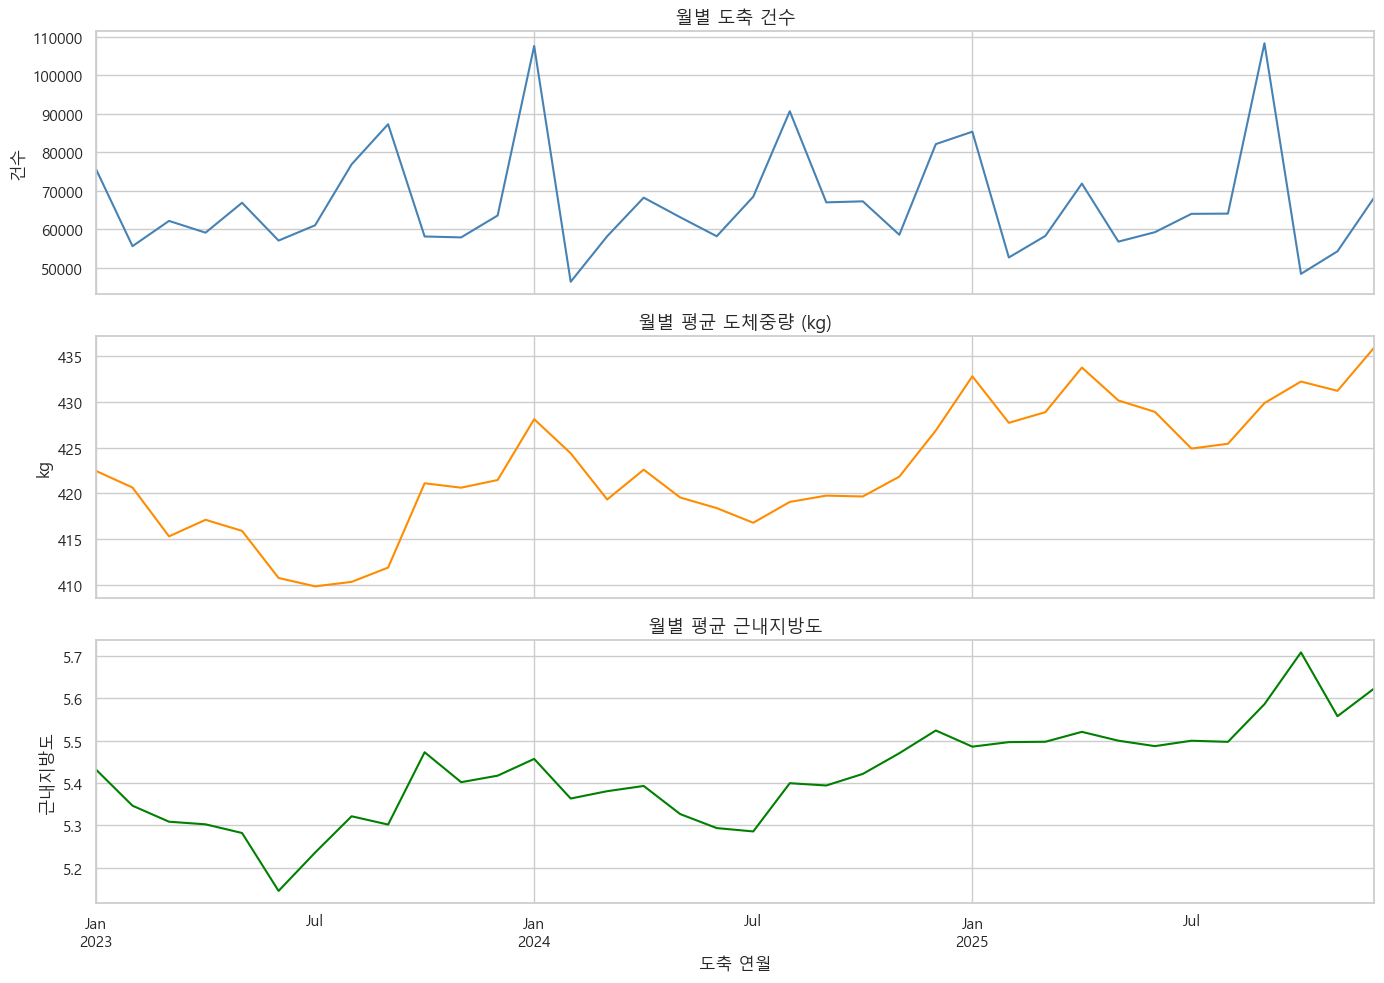

In [19]:
train['ABATT_DATE'] = pd.to_datetime(train['ABATT_DATE'])
train['도축연월'] = train['ABATT_DATE'].dt.to_period('M')

monthly = train.groupby('도축연월').agg(
    건수=('LAST_GRADE', 'size'),
    평균중량=('WEIGHT', 'mean'),
    평균근내지방도=('INSFAT', 'mean')
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

monthly['건수'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('월별 도축 건수', fontsize=13)
axes[0].set_ylabel('건수')

monthly['평균중량'].plot(ax=axes[1], color='darkorange')
axes[1].set_title('월별 평균 도체중량 (kg)', fontsize=13)
axes[1].set_ylabel('kg')

monthly['평균근내지방도'].plot(ax=axes[2], color='green')
axes[2].set_title('월별 평균 근내지방도', fontsize=13)
axes[2].set_ylabel('근내지방도')

plt.xlabel('도축 연월')
plt.tight_layout()
plt.show()

---
## 11. 기상 데이터 탐색

In [20]:
weather['date'] = pd.to_datetime(weather['date'])
print(f'기간: {weather["date"].min()} ~ {weather["date"].max()}')
print(f'관측소 수: {weather["stn"].nunique()}')
print(f'\n기상 데이터 기초 통계:')
weather.describe().round(2)

기간: 2020-01-01 00:00:00 ~ 2025-12-31 00:00:00
관측소 수: 444

기상 데이터 기초 통계:


,stn,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg
count,973248.00,973248,973248.00,973248.00,973248.00,973248.00,973248.00
mean,590.55,2022-12-31 12:00:00,17.51,2.13,6.98,63.77,0.41
min,90.00,2020-01-01 00:00:00,-99.00,-99.00,-99.00,-99.00,-99.00
25%,426.00,2021-07-01 18:00:00,10.70,0.00,-0.60,60.00,1.00
50%,629.50,2022-12-31 12:00:00,20.00,0.00,8.10,73.40,1.50
75%,785.25,2024-07-01 06:00:00,27.00,0.50,17.80,83.00,2.20
max,964.00,2025-12-31 00:00:00,43.40,438.90,33.30,100.00,22.30
std,243.34,NaN,16.40,19.06,15.99,39.95,11.89


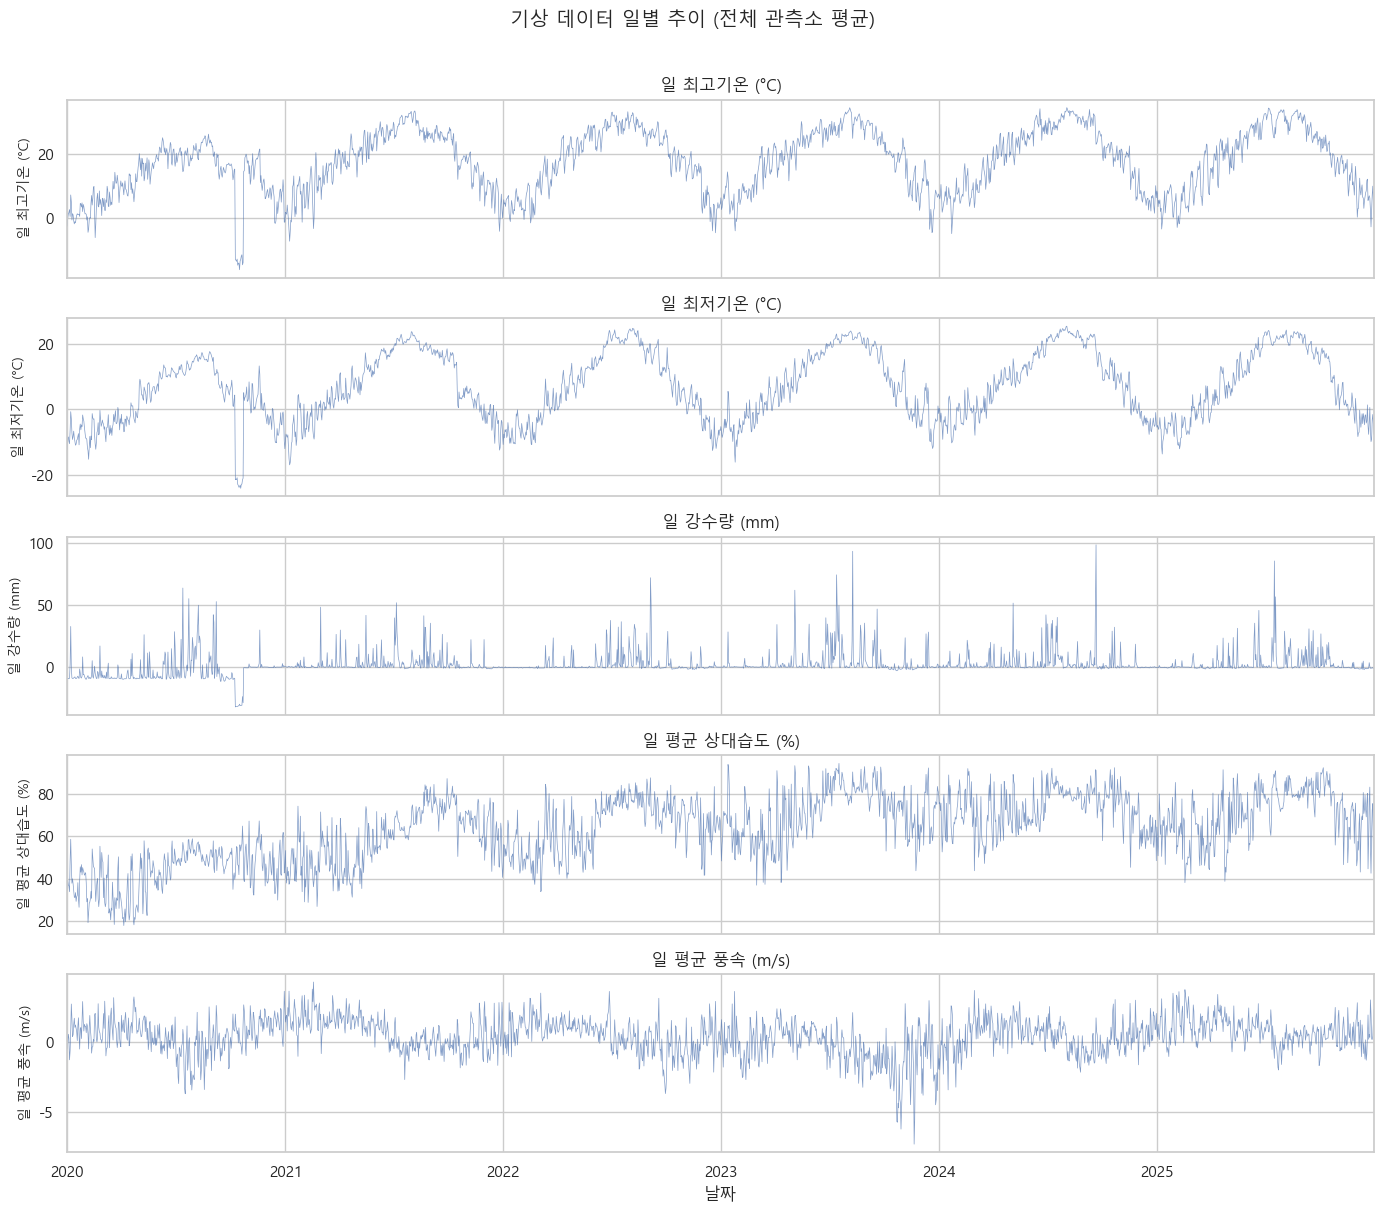

In [21]:
weather_cols = {
    'ta_max': '일 최고기온 (°C)',
    'ta_min': '일 최저기온 (°C)',
    'rn_day': '일 강수량 (mm)',
    'rhm_avg': '일 평균 상대습도 (%)',
    'ws_davg': '일 평균 풍속 (m/s)'
}

fig, axes = plt.subplots(len(weather_cols), 1, figsize=(14, 12), sharex=True)
daily_avg = weather.groupby('date')[list(weather_cols.keys())].mean()

for ax, (col, label) in zip(axes, weather_cols.items()):
    daily_avg[col].plot(ax=ax, linewidth=0.5, alpha=0.7)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=12)

plt.xlabel('날짜')
plt.suptitle('기상 데이터 일별 추이 (전체 관측소 평균)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 12. 사육면적 데이터 탐색

농장 수: 86,703

연도별 평균 사육두수:
  C2023: 31.8마리
  C2024: 23.9마리
  C2025: 17.6마리

평균 축사 면적: 492.3 m²


ValueError: supplied range of [-inf, 297.0] is not finite

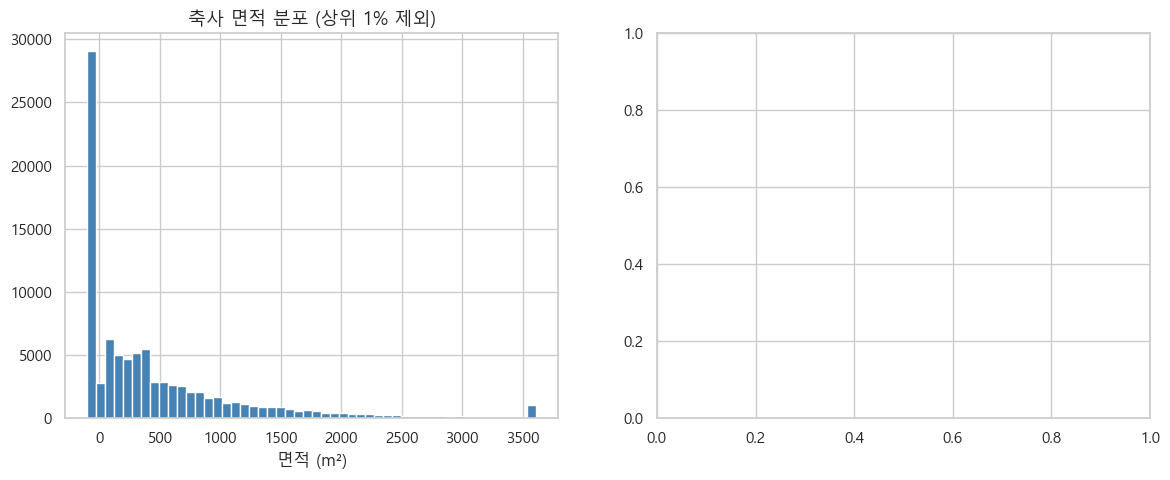

In [22]:
print(f'농장 수: {area["FARM_UNIQUE_NO"].nunique():,}')
print(f'\n연도별 평균 사육두수:')
for col in ['C2023', 'C2024', 'C2025']:
    print(f'  {col}: {area[col].mean():.1f}마리')
print(f'\n평균 축사 면적: {area["AREA"].mean():.1f} m²')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 두당 면적 산출
area['두당면적'] = area['AREA'] / area[['C2023','C2024','C2025']].mean(axis=1)

area['AREA'].clip(upper=area['AREA'].quantile(0.99)).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('축사 면적 분포 (상위 1% 제외)', fontsize=13)
axes[0].set_xlabel('면적 (m²)')

area['두당면적'].clip(upper=area['두당면적'].quantile(0.99)).hist(bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('두당 면적 분포 (상위 1% 제외)', fontsize=13)
axes[1].set_xlabel('두당 면적 (m²/마리)')

plt.tight_layout()
plt.show()

---
## 13. 폐사 데이터 탐색

In [ ]:
death['BIRTH_YMD'] = pd.to_datetime(death['BIRTH_YMD'].astype(str), format='%Y%m%d', errors='coerce')
death['DEAD_YMD'] = pd.to_datetime(death['DEAD_YMD'].astype(str), format='%Y%m%d', errors='coerce')
death['수명_일'] = (death['DEAD_YMD'] - death['BIRTH_YMD']).dt.days
death['수명_월'] = death['수명_일'] / 30.44

print(f'폐사 건수: {len(death):,}')
print(f'평균 수명: {death["수명_월"].mean():.1f}개월')
print(f'폐사일 범위: {death["DEAD_YMD"].min()} ~ {death["DEAD_YMD"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

death['수명_월'].clip(upper=120).hist(bins=60, ax=axes[0], color='indianred')
axes[0].set_title('폐사 개체 수명 분포', fontsize=13)
axes[0].set_xlabel('수명 (개월)')
axes[0].axvline(death['수명_월'].median(), color='black', linestyle='--', label=f'중앙값: {death["수명_월"].median():.0f}개월')
axes[0].legend()

death.set_index('DEAD_YMD').resample('M').size().plot(ax=axes[1], color='indianred')
axes[1].set_title('월별 폐사 건수 추이', fontsize=13)
axes[1].set_ylabel('건수')
axes[1].set_xlabel('날짜')

plt.tight_layout()
plt.show()

---
## 14. 혈통 데이터 탐색

In [ ]:
print(f'전체 개체 수: {lineage["CATTLE_NO"].nunique():,}')
print(f'고유 부(아비) 수: {lineage["FATHER_CATTLE_NO"].nunique():,}')
print(f'고유 KPN 번호 수: {lineage["KPN_NO"].nunique():,}')

# 아비별 자손 수 분포
father_counts = lineage['FATHER_CATTLE_NO'].value_counts()
print(f'\n아비별 자손 수 통계:')
print(father_counts.describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
father_counts.clip(upper=father_counts.quantile(0.95)).hist(bins=50, ax=ax, color='mediumpurple')
ax.set_title('아비별 자손 수 분포 (상위 5% 제외)', fontsize=13)
ax.set_xlabel('자손 수')
ax.set_ylabel('아비 수')
plt.tight_layout()
plt.show()

---
## 15. 경락가격 분석

In [ ]:
cost_valid = train[train['COST_AMT'].notna()].copy()
print(f'경락가격 유효 건수: {len(cost_valid):,} ({len(cost_valid)/len(train)*100:.1f}%)')
print(f'평균 경락가격: {cost_valid["COST_AMT"].mean():,.0f}원')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 육질등급별 경락가격
sns.boxplot(data=cost_valid, x='육질등급', y='COST_AMT', order=quality_order[:-1],
            ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('육질등급별 경락가격', fontsize=13)
axes[0].set_ylabel('경락가격 (원)')
axes[0].set_xlabel('육질등급')

# 근내지방도 vs 경락가격
sns.boxplot(data=cost_valid, x='INSFAT', y='COST_AMT', ax=axes[1], palette='YlOrRd')
axes[1].set_title('근내지방도별 경락가격', fontsize=13)
axes[1].set_ylabel('경락가격 (원)')
axes[1].set_xlabel('근내지방도')

plt.tight_layout()
plt.show()

---
## 16. 데이터 조인 가능성 확인

```
hanwoo_train (메인)
  ├── stn ──────────── hanwoo_weather.stn
  ├── FARM_UNIQUE_NO ─ hanwoo_area.FARM_UNIQUE_NO
  ├── FARM_UNIQUE_NO ─ hanwoo_death.FARM_UNIQUE_NO
  └── CATTLE_NO ────── hanwoo_lineage.CATTLE_NO
```

In [ ]:
# 조인 키 매칭률 확인
train_stn = set(train['stn'].unique())
weather_stn = set(weather['stn'].unique())
print(f'[stn] train: {len(train_stn)}개, weather: {len(weather_stn)}개, 교집합: {len(train_stn & weather_stn)}개')

train_farm = set(train['FARM_UNIQUE_NO'].unique())
area_farm = set(area['FARM_UNIQUE_NO'].unique())
death_farm = set(death['FARM_UNIQUE_NO'].unique())
print(f'[FARM_UNIQUE_NO] train: {len(train_farm):,}개')
print(f'  → area 매칭: {len(train_farm & area_farm):,}개 ({len(train_farm & area_farm)/len(train_farm)*100:.1f}%)')
print(f'  → death 매칭: {len(train_farm & death_farm):,}개 ({len(train_farm & death_farm)/len(train_farm)*100:.1f}%)')

train_cattle = set(train['CATTLE_NO'].unique())
lineage_cattle = set(lineage['CATTLE_NO'].unique())
print(f'[CATTLE_NO] train: {len(train_cattle):,}개, lineage: {len(lineage_cattle):,}개, 매칭: {len(train_cattle & lineage_cattle):,}개 ({len(train_cattle & lineage_cattle)/len(train_cattle)*100:.1f}%)')

---
## 16. 계절별 등급 분포

pipeline.py는 도축월·출생월을 계절로 변환해 피처로 사용. 계절이 실제로 등급과 연관이 있는지 확인.

In [ ]:
train["ABATT_DATE"] = pd.to_datetime(train["ABATT_DATE"], errors="coerce")
train["abatt_month"] = train["ABATT_DATE"].dt.month
train["abatt_season"] = train["abatt_month"].map(
    lambda m: "봄(3-5)" if m in [3,4,5] else "여름(6-8)" if m in [6,7,8]
    else "가을(9-11)" if m in [9,10,11] else "겨울(12-2)")

train["BIRTH_YMD"] = pd.to_datetime(train["BIRTH_YMD"].astype(str), format="%Y%m%d", errors="coerce")
train["birth_month"] = train["BIRTH_YMD"].dt.month
train["birth_season"] = train["birth_month"].map(
    lambda m: "봄(3-5)" if m in [3,4,5] else "여름(6-8)" if m in [6,7,8]
    else "가을(9-11)" if m in [9,10,11] else "겨울(12-2)")

season_order = ["봄(3-5)", "여름(6-8)", "가을(9-11)", "겨울(12-2)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
        axes,
        ["abatt_season", "birth_season"],
        ["도축 계절별 고등급(1++·1+) 비율", "출생 계절별 고등급(1++·1+) 비율"]):
    rate = (train.groupby(col)["육질등급"]
            .apply(lambda x: x.isin(["1++","1+"]).mean())
            .reindex(season_order))
    rate.plot.bar(ax=ax, color=sns.color_palette("coolwarm_r", 4))
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("고등급 비율")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(train["육질등급"].isin(["1++","1+"]).mean(),
               color="red", linestyle="--", linewidth=1, label="전체 평균")
    ax.legend()
plt.suptitle("계절별 고등급 비율", fontsize=15)
plt.tight_layout()
plt.show()

print("도축 계절별 고등급 비율:")
print(train.groupby("abatt_season")["육질등급"]
      .apply(lambda x: x.isin(["1++","1+"]).mean())
      .reindex(season_order).round(4))

---
## 17. 온열지수(THI) × 등급 분석

pipeline.py의 핵심 기상 피처. THI = (1.8×평균기온+32) − (0.55−0.0055×습도)×(1.8×평균기온−26)

- THI ≥ 80: 중등도 열 스트레스 (`heat2d`)
- THI ≥ 85: 심각한 열 스트레스 (`heat3d`)

In [ ]:
weather["date"] = pd.to_datetime(weather["date"])
weather["ta_avg"] = (weather["ta_max"] + weather["ta_min"]) / 2
weather["THI"] = ((1.8 * weather["ta_avg"] + 32)
                  - (0.55 - 0.0055 * weather["rhm_avg"])
                  * (1.8 * weather["ta_avg"] - 26))
weather["year"]  = weather["date"].dt.year
weather["month"] = weather["date"].dt.month

thi_monthly = weather.groupby(["stn","year","month"]).agg(
    thi_mean=("THI","mean"),
    heat2d=("THI", lambda x: (x >= 80).sum()),
    heat3d=("THI", lambda x: (x >= 85).sum()),
).reset_index()

train["abatt_year"] = train["ABATT_DATE"].dt.year
thi_train = train.merge(
    thi_monthly.rename(columns={"year":"abatt_year","month":"abatt_month"}),
    on=["stn","abatt_year","abatt_month"], how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# THI 평균 × 육질등급
thi_train.boxplot(column="thi_mean", by="육질등급", ax=axes[0], order=quality_order[:-1])
axes[0].set_title("도축월 평균 THI × 육질등급")
axes[0].set_xlabel("육질등급"); axes[0].set_ylabel("THI")
plt.sca(axes[0]); plt.title("도축월 평균 THI × 육질등급")

# 중등도 열스트레스 일수 × 육질등급
thi_train.groupby("육질등급")["heat2d"].mean().reindex(quality_order[:-1]).plot.bar(
    ax=axes[1], color="tomato")
axes[1].set_title("도축월 THI≥80 일수 평균 × 육질등급")
axes[1].set_ylabel("일수"); axes[1].set_xlabel("육질등급")
axes[1].tick_params(axis="x", rotation=0)

# 연도별 월평균 THI
thi_pivot = weather.groupby(["year","month"])["THI"].mean().unstack(0)
thi_pivot.plot(ax=axes[2], alpha=0.7, legend=True)
axes[2].axhline(80, color="orange", linestyle="--", linewidth=1.5, label="THI=80(중등도)")
axes[2].axhline(85, color="red",    linestyle="--", linewidth=1.5, label="THI=85(심각)")
axes[2].set_title("연도별 월평균 THI (전체 관측소 평균)")
axes[2].set_xlabel("월"); axes[2].set_ylabel("THI")
axes[2].legend(fontsize=8)

plt.suptitle("온열지수(THI) 분석", fontsize=15)
plt.tight_layout()
plt.show()

---
## 18. 혈통 피처 유효성 검증

pipeline.py는 훈련 데이터의 INSFAT으로 **아비(FATHER_CATTLE_NO)·KPN별 평균 근내지방**을 계산해
테스트에 간접 적용. 아비가 다르면 자손의 근내지방 분포도 실제로 다른지 확인.

In [ ]:
train_lin = train.merge(
    lineage[["CATTLE_NO","FATHER_CATTLE_NO","KPN_NO"]], on="CATTLE_NO", how="left")

father_stat = (train_lin.dropna(subset=["INSFAT","FATHER_CATTLE_NO"])
               .groupby("FATHER_CATTLE_NO")["INSFAT"]
               .agg(["mean","count"])
               .query("count >= 30")
               .rename(columns={"mean":"father_insfat","count":"n"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(father_stat["father_insfat"], bins=40, color="mediumpurple", edgecolor="white")
axes[0].set_title(f"아비별 평균 근내지방도 분포 (자손 30마리+ 아비 {len(father_stat):,}명)", fontsize=12)
axes[0].set_xlabel("평균 근내지방도"); axes[0].set_ylabel("아비 수")
mu = father_stat["father_insfat"].mean()
axes[0].axvline(mu, color="red", linestyle="--", label=f"평균 {mu:.2f}")
axes[0].legend()

q25 = father_stat["father_insfat"].quantile(0.25)
q75 = father_stat["father_insfat"].quantile(0.75)
top_f = father_stat[father_stat["father_insfat"] >= q75].index
bot_f = father_stat[father_stat["father_insfat"] <= q25].index
top_rate = (train_lin[train_lin["FATHER_CATTLE_NO"].isin(top_f)]["육질등급"]
            .value_counts(normalize=True).reindex(quality_order[:-1]).fillna(0))
bot_rate = (train_lin[train_lin["FATHER_CATTLE_NO"].isin(bot_f)]["육질등급"]
            .value_counts(normalize=True).reindex(quality_order[:-1]).fillna(0))

x = range(len(quality_order[:-1])); w = 0.35
axes[1].bar([i-w/2 for i in x], top_rate.values, w,
            label=f"상위 아비 (INSFAT≥{q75:.1f})", color="steelblue")
axes[1].bar([i+w/2 for i in x], bot_rate.values, w,
            label=f"하위 아비 (INSFAT≤{q25:.1f})", color="tomato")
axes[1].set_title("아비 근내지방 수준별 자손 육질등급 비율", fontsize=12)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(quality_order[:-1])
axes[1].set_ylabel("비율"); axes[1].legend()

plt.tight_layout(); plt.show()
cols = ["1++","1+"]
print(f"상위 아비 자손 고등급 비율: {top_rate[cols].sum():.3f}")
print(f"하위 아비 자손 고등급 비율: {bot_rate[cols].sum():.3f}")

---
## 19. 농장 규모·밀도 × 등급 분석

pipeline.py 피처: `avg_cattle`(평균 사육두수), `density`(두당 면적), `death_rate`(폐사율)

In [ ]:
area2 = pd.read_csv("data/hanwoo_area.csv", encoding="utf-8-sig")
area2["avg_cattle"] = area2[["C2023","C2024","C2025"]].mean(axis=1)
area2["density"]    = area2["avg_cattle"] / area2["AREA"].replace(0, np.nan)

train_farm = train.merge(
    area2[["FARM_UNIQUE_NO","avg_cattle","density"]], on="FARM_UNIQUE_NO", how="left")

train_farm["규모"] = pd.cut(train_farm["avg_cattle"],
    bins=[0,20,50,100,200,float("inf")],
    labels=["소규모(<20)","중소(20-50)","중형(50-100)","대형(100-200)","초대형(200+)"])
train_farm["밀도구간"] = pd.qcut(
    train_farm["density"].clip(upper=train_farm["density"].quantile(0.99)),
    q=4, labels=["저밀도","중저","중고","고밀도"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ["규모","밀도구간"], ["농장 규모별","사육 밀도별"]):
    rate = (train_farm.groupby(col, observed=True)["육질등급"]
            .apply(lambda x: x.isin(["1++","1+"]).mean()))
    rate.plot.bar(ax=ax, color=sns.color_palette("Blues_d", len(rate)))
    ax.set_title(f"{title} 고등급(1++·1+) 비율", fontsize=13)
    ax.set_ylabel("고등급 비율"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(train["육질등급"].isin(["1++","1+"]).mean(),
               color="red", linestyle="--", linewidth=1, label="전체 평균")
    ax.legend()
plt.suptitle("농장 특성 × 고등급 비율", fontsize=15)
plt.tight_layout()
plt.show()

---
## 요약

### 주요 발견사항
- **최종 등급**은 육질등급(1++~3) + 육량등급(A~C) 조합으로 총 16개 클래스
- **근내지방도(INSFAT)**가 육질등급과 가장 강한 연관성
- **성별(JUDGE_SEX)**에 따라 등급 분포가 크게 다름 (거세가 고등급 비율 높을 것으로 예상)
- **경락가격**은 등급과 강한 양의 상관관계

### 다음 단계
1. 기상 데이터 병합: `stn` + 도축일 기준 사육 기간 중 기상 피처 집계
2. 사육면적 데이터 병합: 두당 면적, 사육 규모 등 파생변수 생성
3. 혈통 데이터 병합: 아비·KPN별 등급 통계 파생변수
4. 결측값 처리 전략 수립
5. 등급 예측 모델 구축